In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil
import scipy.optimize

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants[['gene', 'variant']] = who_variants['mutation'].str.split('_', n=1, expand=True)
who_variants_V2 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean_V2.csv")#.rename(columns={'POS': 'OLD_POS'})

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

MIC_ML = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/MIC_ML/data_with_paths.csv")
MIC_ML_og = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv")
vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF"
MIC_ML.shape

4411532


(1718, 75)

In [2]:
# # locus_list = ['pncA_lowAF', 'panD_lowAF', 'rpsA_lowAF', 'clpC1_lowAF']
# locus_list = ['rpoBC_lowAF', 'rpoA_lowAF']
# seq_data_path = os.path.join(results_path, "RIF_rpoABC")
# kwargs = yaml.safe_load(open("../config_files/config_rif.yaml"))

In [3]:
# drug = kwargs["drug"]

# # get table for phenotypes and add the reference strain to match the format of the FASTA files
# df_phenos = pd.read_csv(kwargs['phenotype_file'])
# print(f"Found phenotypes for {len(df_phenos)} strains")
# df_phenos.loc[-1, ['ROLLINGDB_ID', 'category']] = np.array(["MT_H37Rv", "reference"], dtype=object)

# # make table of all genotypes. Index is the identifier
# df_genos = make_genotype_df(locus_list, kwargs['genotype_input_directory'])

# df_genos.index = [name.split(".")[0] for name in df_genos.index]
# df_phenos["ROLLINGDB_ID"] = [name for name in df_phenos["ROLLINGDB_ID"]]
# df_genos.index.rename('ROLLINGDB_ID', inplace=True)

# # this makes life easier later. Keep H37Rv in this      
# df_genos = df_phenos[["category", "ROLLINGDB_ID"]].merge(df_genos, on="ROLLINGDB_ID", how="inner")

# # Apply one-hot encoding function to get each isolate sequence
# print('Making one hot encoding for...')
# for locus in locus_list:
#     print("...", locus)
#     lengths = [len(seq) for seq in df_genos[locus]]
#     assert len(np.unique(lengths)) == 1
#     df_genos[locus + "_one_hot"] = df_genos[locus].apply(np.vectorize(get_one_hot))
    
# if "category" in df_genos and "category" in df_phenos:
#     del df_genos["category"]

# # combined dataframe of all genotypes and phenotypes
# df_geno_pheno = df_phenos.merge(df_genos, how='inner', on="ROLLINGDB_ID")
# print(df_geno_pheno.shape)

# # this is to check that df_geno_pheno is in the same order as df_phenos.
# assert sum(df_phenos.ROLLINGDB_ID.values != df_geno_pheno.ROLLINGDB_ID.values) == 0

# # Create a one-hot-encoding matrix with dimensions
# # num_isolate x 5 x locus_length x num_loci
# X_all = create_X(df_geno_pheno)
# X_sparse = sparse.COO(X_all)

Found phenotypes for 9001 strains
2 loci!
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoBC_lowAF.fasta
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoA_lowAF.fasta
Making one hot encoding for...
... rpoBC_lowAF
... rpoA_lowAF
(9002, 23)


In [4]:
# # H37Rv is the last row, so remove it before saving to avoid redundancy 
# X_data = X_sparse[:-1, :]
# print(f"Full data set shape: {X_data.shape}")
# sparse.save_npz(os.path.join(seq_data_path, "pkl_sparse_full_lowAF.npz"), X_data, compressed=False)

Full data set shape: (9001, 5, 8569, 2)


In [5]:
# # make gene peptide lengths dataframe
# fasta_dir = kwargs["genotype_input_directory"]
# df_phenos = pd.read_csv(kwargs["phenotype_file"])

# gene_coords, sense_dict = get_gene_coords(locus_list, fasta_dir)
# X_matrix_H37Rv_coords = make_h37rv_coordinates(gene_coords, locus_list, fasta_dir)

# seq_all_loci = {}

# for locus in locus_list:

#     locus_idx = locus_list.index(locus)
#     locus_pos_lst = []

#     seq_lst = [(seq.id, str(seq.seq)) for seq in SeqIO.parse(os.path.join(fasta_dir, f"{locus}.fasta"), "fasta")]        
#     aln_len = len(seq_lst[0][1])
#     seq_df = pd.DataFrame(seq_lst)
#     seq_df.columns = ["Isolate", "Seq"]
    
#     # fasta files contain the full VCF file name, without the .vcf extension
#     # The ROLLINGDB_ID column is just the isolate name, not the full file path
#     seq_df["Isolate"] = [isolate.split(".")[0] for isolate in seq_df["Isolate"].values]
#     seq_df = seq_df.set_index("Isolate")
#     seq_df = seq_df.loc[np.concatenate([df_phenos["ROLLINGDB_ID"].values, np.array(["MT_H37Rv"])])]
    
#     nuc_matrix = seq_df["Seq"].str.split("", expand=True)
#     nuc_matrix = nuc_matrix.iloc[:, 1:-1]
    
#     pos_including_indels = X_matrix_H37Rv_coords[:nuc_matrix.shape[1], locus_idx]
#     k = 0
    
#     for pos in pos_including_indels:
#         if pd.isnull(pos):
#             locus_pos_lst.append(f"{locus}_{k}")
#             k += 1
#         else:
#             locus_pos_lst.append(pos)

#     assert sum(pd.isnull(locus_pos_lst)) == 0
#     nuc_matrix.columns = locus_pos_lst
#     seq_all_loci[locus] = nuc_matrix

In [6]:
# pickle.dump(seq_all_loci, open(os.path.join(seq_data_path, "seqDict_lowAF.pkl"), "wb"))

# locus_peptide_lengths = make_CDS_length_df(locus_list, kwargs["genotype_input_directory"], os.path.join(seq_data_path, "seqDict_lowAF.pkl"))

# # keep index because that's the samples column
# locus_peptide_lengths.to_csv(os.path.join(seq_data_path, "gene_peptide_lengths_lowAF.csv"))

In [21]:
gyrBA_seq = pd.DataFrame([(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA.fasta", "fasta")])
gyrBA_seq_lowAF = pd.DataFrame([(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA_lowAF.fasta", "fasta")])

gyrBA_seq.columns = ['Isolate', 'Seq']
gyrBA_seq_lowAF.columns = ['Isolate', 'Seq_lowAF']

gyrBA_seq = gyrBA_seq.merge(gyrBA_seq_lowAF)
gyrBA_seq.shape

(1278, 3)

In [23]:
len(gyrBA_seq.query("Seq != Seq_lowAF"))

59

In [31]:
rpoBC_insertions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoBC_insertion_sites.csv")
rpoBC_insertions_lowAF = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoBC_lowAF_insertion_sites.csv")

In [34]:
rpoBC_insertions.len_insertion.sum(), rpoBC_insertions_lowAF.len_insertion.sum()

(156, 195)

In [38]:
rpoBC_insertions.merge(rpoBC_insertions_lowAF, on='aln_idx', how='outer')

,aln_idx,len_insertion_x,len_insertion_y
0,95,3.0,3
1,328,1.0,1
2,338,21.0,21
3,527,6.0,6
4,780,6.0,6
5,1039,12.0,12
6,1054,12.0,12
7,1787,3.0,3
8,1789,3.0,3
9,1792,3.0,3


In [41]:
# 759310 = start, 1-indexed
317 + 759310, 1999 + 759310

(759627, 761309)

In [59]:
759648-759310

338

In [68]:
RIF_isolate_variants = pd.read_csv(os.path.join(data_path, "RIF/isolate_variants_fixed_annot.csv"))
df_RIF = pd.read_csv(os.path.join(data_path, "RIF/data_for_model.csv"))
df_RIF_val = pd.read_csv(os.path.join(data_path, "RIF/validation_data_for_model.csv"))

In [69]:
df_RIF_val.query("ROLLINGDB_ID in ['KOR-K2016-0168', 'KOR-K2016-0141']")

,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF_quality,RIF_lower_bound_original,RIF_midpoint_original,RIF_upper_bound_original,MEDIA_CC,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,WHO_Cat1_mutation
363,KOR-K2016-0141,Korea,JATA-KIT,NaN,NaN,Not specified,MGIT960/MGIT7h9,NaN,24.0,28.0,32.0,1.0,12.0,14.0,16.0,1
389,KOR-K2016-0168,Korea,JATA-KIT,NaN,NaN,Not specified,MGIT960/MGIT7h9,NaN,24.0,28.0,32.0,1.0,12.0,14.0,16.0,1


In [70]:
RIF_isolate_variants.query("Isolate in ['KOR-K2016-0168', 'KOR-K2016-0141']")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
15342,761155,C,T,PASS,0.99,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,KOR-K2016-0168,rpoB_p.Ser450Leu
15343,761309,C,CCCGTTCGGGTTCATCGAA,PASS,0.74,rpoB,conservative_inframe_insertion,c.1504_1521dupCCGTTCGGGTTCATCGAA,p.Pro502_Glu507dup,KOR-K2016-0168,rpoB_p.Pro502_Glu507dup
15344,761441,C,G,PASS,1.0,rpoB,missense_variant,c.1635C>G,p.Asp545Glu,KOR-K2016-0168,rpoB_p.Asp545Glu
15345,763031,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,KOR-K2016-0168,rpoB_c.3225T>C
15729,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,KOR-K2016-0141,rpoB_p.Ser450Leu
15730,761309,C,CCCGTTCGGGTTCATCGAA,PASS,0.71,rpoB,conservative_inframe_insertion,c.1504_1521dupCCGTTCGGGTTCATCGAA,p.Pro502_Glu507dup,KOR-K2016-0141,rpoB_p.Pro502_Glu507dup
15731,761441,C,G,PASS,1.0,rpoB,missense_variant,c.1635C>G,p.Asp545Glu,KOR-K2016-0141,rpoB_p.Asp545Glu
15732,763031,T,C,PASS,0.99,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,KOR-K2016-0141,rpoB_c.3225T>C


In [46]:
RIF_isolate_variants.query("POS in [759627, 761309]")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
8324,759627,A,ACTTGACACCGTGGTCTTAGTC,PASS,0.41,Rv0666-rpoB,intergenic_region,n.759627_759628insCTTGACACCGTGGTCTTAGTC,.,ERR4828591,Rv0666-rpoB_.
10716,759627,A,C,PASS,1.0,Rv0666-rpoB,intergenic_region,n.759627A>C,.,ERR4831412,Rv0666-rpoB_.
15343,761309,C,CCCGTTCGGGTTCATCGAA,PASS,0.74,rpoB,conservative_inframe_insertion,c.1504_1521dupCCGTTCGGGTTCATCGAA,p.Pro502_Glu507dup,KOR-K2016-0168,rpoB_p.Pro502_Glu507dup
15730,761309,C,CCCGTTCGGGTTCATCGAA,PASS,0.71,rpoB,conservative_inframe_insertion,c.1504_1521dupCCGTTCGGGTTCATCGAA,p.Pro502_Glu507dup,KOR-K2016-0141,rpoB_p.Pro502_Glu507dup


In [ ]:
if (record.POS == 759627 and record.ALT == 'ACTTGACACCGTGGTCTTAGTC' and record.AF <= 0.75) or (record.POS == 761309 and record.ALT == 'CCCGTTCGGGTTCATCGAA' and record.AF <= 0.75)

In [63]:
RIF_isolate_variants.query("Isolate=='KOR-K2016-0168'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
15342,761155,C,T,PASS,0.99,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,KOR-K2016-0168,rpoB_p.Ser450Leu
15343,761309,C,CCCGTTCGGGTTCATCGAA,PASS,0.74,rpoB,conservative_inframe_insertion,c.1504_1521dupCCGTTCGGGTTCATCGAA,p.Pro502_Glu507dup,KOR-K2016-0168,rpoB_p.Pro502_Glu507dup
15344,761441,C,G,PASS,1.0,rpoB,missense_variant,c.1635C>G,p.Asp545Glu,KOR-K2016-0168,rpoB_p.Asp545Glu
15345,763031,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,KOR-K2016-0168,rpoB_c.3225T>C


In [67]:
who_variants_V2.query("mutation.str.contains('rpoB_p.Glu507')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
41042,Rifampicin,rpoB,p.Glu507Lys,rpoB_p.Glu507Lys,1,missense_variant,1.0,2.0,1.0,1.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,761325


In [58]:
RIF_isolate_variants.query("Isolate=='ERR4828591'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
8324,759627,A,ACTTGACACCGTGGTCTTAGTC,PASS,0.41,Rv0666-rpoB,intergenic_region,n.759627_759628insCTTGACACCGTGGTCTTAGTC,.,ERR4828591,Rv0666-rpoB_.
8325,759648,C,CCTTGACACCGTGGTCTTAGTC,PASS,.,Rv0666-rpoB,intergenic_region,n.759648_759649insCTTGACACCGTGGTCTTAGTC,.,ERR4828591,Rv0666-rpoB_.
8326,763031,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,ERR4828591,rpoB_c.3225T>C


In [62]:
who_variants_V2.query("mutation.str.contains('-160') & gene=='rpoB'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
40240,Rifampicin,rpoB,c.-160T>C,rpoB_c.-160T>C,1,upstream_gene_variant,1.0,4.0,0.0,4.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,759647
40241,Rifampicin,rpoB,c.-160T>G,rpoB_c.-160T>G,1,upstream_gene_variant,1.0,2.0,0.0,2.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,759647
40242,Rifampicin,rpoB,c.-161_-160insA,rpoB_c.-161_-160insA,1,upstream_gene_variant,1.0,0.0,0.0,0.0,...,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0,759646


In [52]:
len("ACTTGACACCGTGGTCTTAGTC")-1, len("CCCGTTCGGGTTCATCGAA")-1

(21, 18)

In [50]:
df_RIF.query("ROLLINGDB_ID in ['ERR4828591', 'KOR-K2016-0168', 'KOR-K2016-0141']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
6819,ERR4828591,ERS5317664,site.08.subj.24TB00-047.lab.2433.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.0,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set


# Are there any Microvariants in MXF and LEV Samples Predicted S but actually R?

No, extremely low prevalence in test set of MXF, and no prevalence in LEV.

In [3]:
df_MXF = pd.read_csv(os.path.join(data_path, "MXF", "data_for_model.csv"))
MXF_pred = pd.read_csv(os.path.join(results_path, "MXF_gyrBA_peptide_lineage", "test_predictions.csv"))
MXF_pred["y_pred_exp"] = np.exp2(MXF_pred["y_pred"])

MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF", "isolate_variants_fixed_annot.csv"))
MXF_isolate_variants["AF"] = MXF_isolate_variants["AF"].replace('.', 0.76).astype(float)

LEV_pred = pd.read_csv(os.path.join(results_path, "LEV_gyrBA_peptide_lineage", "test_predictions.csv"))
LEV_pred["y_pred_exp"] = np.exp2(LEV_pred["y_pred"])

LEV_isolate_variants = pd.read_csv(os.path.join(data_path, "LEV", "isolate_variants_fixed_annot.csv"))
LEV_isolate_variants["AF"] = LEV_isolate_variants["AF"].replace('.', 0.76).astype(float)

In [4]:
# pred R, actual S = FP
MXF_pred.query("y_pred_exp > 0.5 & upper < 0.5")

,Isolate,y_test,lower,upper,y_pred,compute_error,y_pred_exp
1437,Peru5147,-4.0,0.0,0.125,1.081688,1,2.116511


In [6]:
MXF_isolate_variants.query("Isolate=='Peru5147'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
26531,7362,G,C,PASS,1.00,gyrA,missense_variant,c.61G>C,p.Glu21Gln,Peru5147,gyrA_p.Glu21Gln
26532,7566,G,A,PASS,0.99,gyrA,missense_variant,c.265G>A,p.Asp89Asn,Peru5147,gyrA_p.Asp89Asn
26533,7585,G,C,PASS,1.00,gyrA,missense_variant,c.284G>C,p.Ser95Thr,Peru5147,gyrA_p.Ser95Thr
26534,9304,G,A,PASS,1.00,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,Peru5147,gyrA_p.Gly668Asp


In [5]:
# pred R, actual S = FP
LEV_pred.query("y_pred_exp > 1 & upper < 1")

,Isolate,y_test,lower,upper,y_pred,compute_error,y_pred_exp


In [34]:
# contains a gyrA truncation at Glu280fs
LEV_pred.query("Isolate=='ERR4822407'")

,Isolate,y_test,lower,upper,y_pred,compute_error,y_pred_exp
285,ERR4822407,-2.434403,0.12,0.25,-1.891871,1,0.269457


In [42]:
who_variants.query("drug in ['Levofloxacin', 'Moxifloxacin'] & effect.str.contains('stop')")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
29658,Levofloxacin,gyrA,p.Ter839delins???,gyrA_p.Ter839delins???,1,stop_lost,"(see ""Genomic_coordinates"" sheet)",1.0,0.0,0.0,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0
29659,Levofloxacin,gyrA,p.Ter839ext*?,gyrA_p.Ter839ext*?,1,stop_lost,"(see ""Genomic_coordinates"" sheet)",1.0,0.0,0.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
29861,Levofloxacin,gyrB,c.2027A>G,gyrB_c.2027A>G,1,stop_retained_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
33520,Moxifloxacin,gyrA,p.Ter839ext*?,gyrA_p.Ter839ext*?,1,stop_lost,"(see ""Genomic_coordinates"" sheet)",1.0,0.0,0.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
33702,Moxifloxacin,gyrB,c.2027A>G,gyrB_c.2027A>G,1,stop_retained_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [11]:
LEV_isolates_FN = LEV_pred.query("y_pred_exp <= 1 & upper > 1").Isolate.values
LEV_pred.query("y_pred_exp <= 1 & upper > 1").shape, LEV_pred.shape

((25, 7), (1400, 7))

In [13]:
# number of false negatives with microvariants in the coding regions of gyrA and gyrB
# MXF_isolate_variants.query("Isolate in @isolates_FN & ((POS >= 5240 & POS <= 7267) | (POS >= 7302 & POS <= 9818)) & AF < 0.75")
LEV_isolate_variants.query("Isolate in @LEV_isolates_FN & AF <= 0.75")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation


In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9918" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/ERR4822373/pilon/ERR4822373.eff.vcf

In [67]:
who_variants.query("variant=='gyrA_p.Ser91Pro'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
29655,Levofloxacin,gyrA,p.Ser91Pro,gyrA_p.Ser91Pro,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,277.0,232.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1
33517,Moxifloxacin,gyrA,p.Ser91Pro,gyrA_p.Ser91Pro,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,208.0,150.0,...,NaN,1) Assoc w R,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,NaN,F,1


In [15]:
# pred S, actual R = FN -- LOOK FOR MICROVARIANTS!
MXF_isolates_FN = MXF_pred.query("y_pred_exp <= 0.5 & upper > 0.5").Isolate.values
MXF_pred.query("y_pred_exp <= 0.5 & upper > 0.5").shape, MXF_pred.shape

((37, 7), (1471, 7))

In [17]:
# number of false negatives with microvariants in the coding regions of gyrA and gyrB
# MXF_isolate_variants.query("Isolate in @isolates_FN & ((POS >= 5240 & POS <= 7267) | (POS >= 7302 & POS <= 9818)) & AF < 0.75")
MXF_isolate_variants.query("Isolate in @MXF_isolates_FN & AF <= 0.75").merge(who_variants.query("drug=='Moxifloxacin'"), left_on="mutation", right_on="variant", how="left")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,6620,G,A,Amb,0.27,gyrB,missense_variant,c.1381G>A,p.Asp461Asn,ERR2510847,...,FQ cross-resistance,2) Assoc w R - Interim,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,FQ X-R,F,1.0
1,7563,G,T,Amb,0.67,gyrA,missense_variant,c.262G>T,p.Gly88Cys,ERR4812196,...,NaN,1) Assoc w R,High-level resistance,No change,NaN,NaN,yes,NaN,G,1.0
2,7521,G,T,Amb,0.33,gyrA,missense_variant,c.220G>T,p.Ala74Ser,ERR4812207,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1.0
3,8452,C,T,Amb,0.64,gyrA,missense_variant,c.1151C>T,p.Ala384Val,Peru5038,...,NaN,5) Not assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1.0
4,5077,T,TC,Amb,0.23,Rv0004-gyrB,intergenic_region,n.5077_5078insC,.,SAMN02360569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# CRyPTIC Essential Agreements (for comparing to Lachapelle et al., 2021)

In [18]:
def compute_cryptic_EA(drug, path, thresh):

    test_pred = pd.read_csv(os.path.join(results_path, path, "test_predictions.csv"))
    df_phenos = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    
    test_pred_cryptic = test_pred.loc[test_pred["Isolate"].isin(df_phenos.query("DB_OF_ORIGIN=='CRyPTIC'").ROLLINGDB_ID.values)]
    assert len(test_pred_cryptic) > 0

    # round so that i.e. 0.059999 is included in essential agreement for an isolate with MIC = (0.12, 0.25]
    test_pred_cryptic["y_pred_exp"] = np.round(np.exp2(test_pred_cryptic["y_pred"]), 2)
    
    test_pred_cryptic_R = test_pred_cryptic.query("upper > @thresh")
    test_pred_cryptic_S = test_pred_cryptic.query("upper <= @thresh")

    print(f"CRyPTIC: {len(test_pred_cryptic.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic)}")
    print(f"CRyPTIC-R: {len(test_pred_cryptic_R.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic_R)}")
    print(f"CRyPTIC-S: {len(test_pred_cryptic_S.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic_S)}")

In [19]:
drug = "RIF"
path = "RIF_rpoABC_peptide_lineage"
compute_cryptic_EA(drug, path, 0.5)

CRyPTIC: 0.9696186166774402
CRyPTIC-R: 0.9470499243570348
CRyPTIC-S: 0.9864559819413092


In [20]:
drug = "LEV"
path = "LEV_gyrBA_peptide_lineage"
compute_cryptic_EA(drug, path, 1)

CRyPTIC: 0.9306647605432452
CRyPTIC-R: 0.8451882845188284
CRyPTIC-S: 0.9482758620689655


In [21]:
drug = "MXF"
path = "MXF_gyrBA_peptide_lineage"
compute_cryptic_EA(drug, path, 0.5)

CRyPTIC: 0.9550922213311949
CRyPTIC-R: 0.8677248677248677
CRyPTIC-S: 0.9706994328922496


# Replicates Evaluation

Plot validation loss for the 10 replicates and the actual model on top. 

In [3]:
# plot_histories(os.path.join(results_path, "RIF_rpoABC"), binary=False, patience_epochs=100, replicates=True)

Trained replicate rep_0 for 407 epochs (excluding patience period)
Trained replicate rep_1 for 349 epochs (excluding patience period)
Trained replicate rep_2 for 277 epochs (excluding patience period)
Trained replicate rep_3 for 309 epochs (excluding patience period)
Trained replicate rep_4 for 272 epochs (excluding patience period)
Trained replicate rep_5 for 230 epochs (excluding patience period)
Trained replicate rep_6 for 397 epochs (excluding patience period)
Trained replicate rep_7 for 337 epochs (excluding patience period)
Trained replicate rep_8 for 390 epochs (excluding patience period)
Trained replicate rep_9 for 417 epochs (excluding patience period)


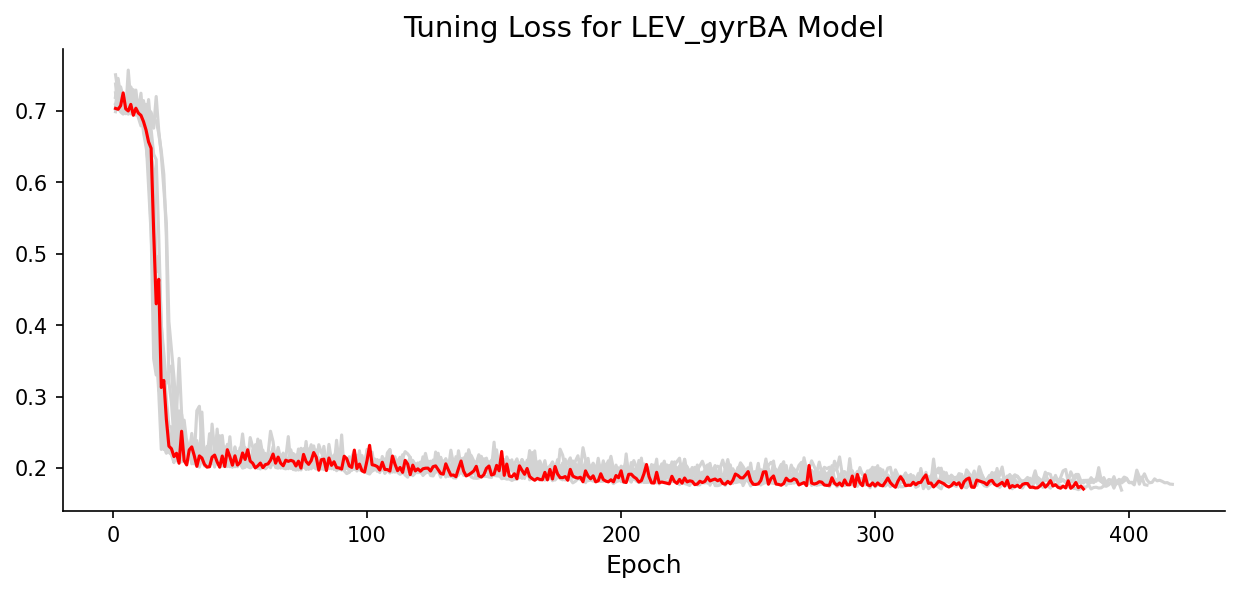

In [4]:
plot_histories(os.path.join(results_path, "LEV_gyrBA"), binary=False, patience_epochs=100, replicates=True)

Trained replicate rep_0 for 667 epochs (excluding patience period)
Trained replicate rep_1 for 922 epochs (excluding patience period)
Trained replicate rep_2 for 1053 epochs (excluding patience period)
Trained replicate rep_3 for 1336 epochs (excluding patience period)
Trained replicate rep_4 for 916 epochs (excluding patience period)
Trained replicate rep_5 for 799 epochs (excluding patience period)
Trained replicate rep_6 for 1432 epochs (excluding patience period)
Trained replicate rep_7 for 774 epochs (excluding patience period)
Trained replicate rep_8 for 1035 epochs (excluding patience period)
Trained replicate rep_9 for 1181 epochs (excluding patience period)


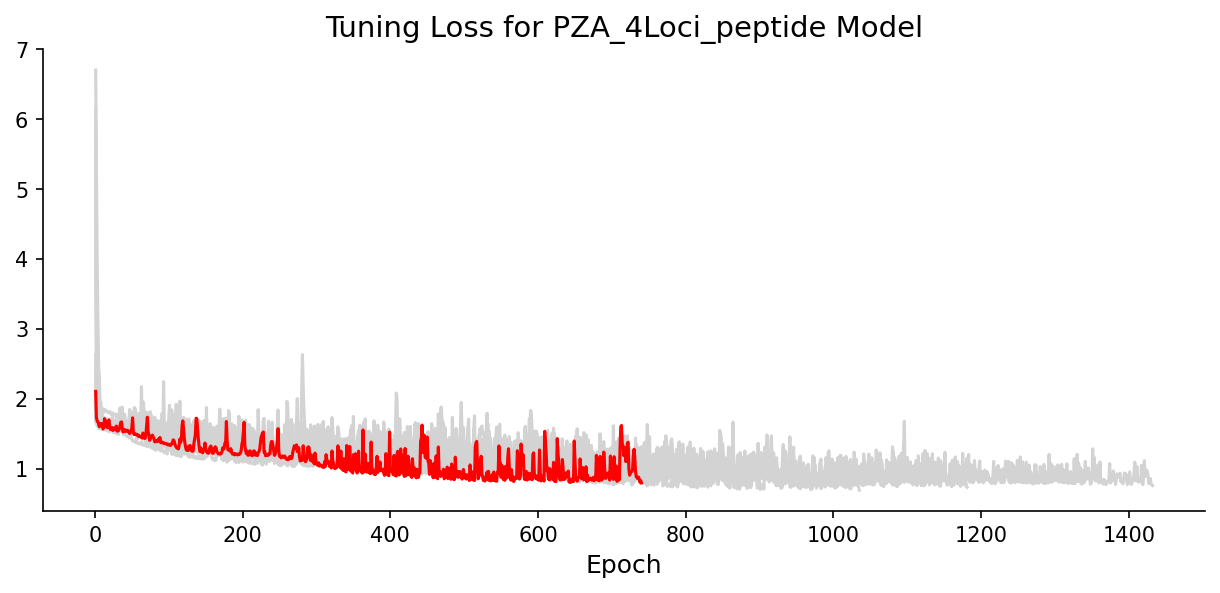

In [2]:
plot_histories(os.path.join(results_path, "PZA_4Loci_peptide"), binary=False, patience_epochs=150, replicates=True)

Trained replicate rep_0 for 715 epochs (excluding patience period)
Trained replicate rep_1 for 234 epochs (excluding patience period)
Trained replicate rep_2 for 742 epochs (excluding patience period)
Trained replicate rep_3 for 1488 epochs (excluding patience period)
Trained replicate rep_4 for 1003 epochs (excluding patience period)
Trained replicate rep_5 for 984 epochs (excluding patience period)
Trained replicate rep_6 for 939 epochs (excluding patience period)
Trained replicate rep_7 for 1209 epochs (excluding patience period)
Trained replicate rep_8 for 1363 epochs (excluding patience period)
Trained replicate rep_9 for 766 epochs (excluding patience period)


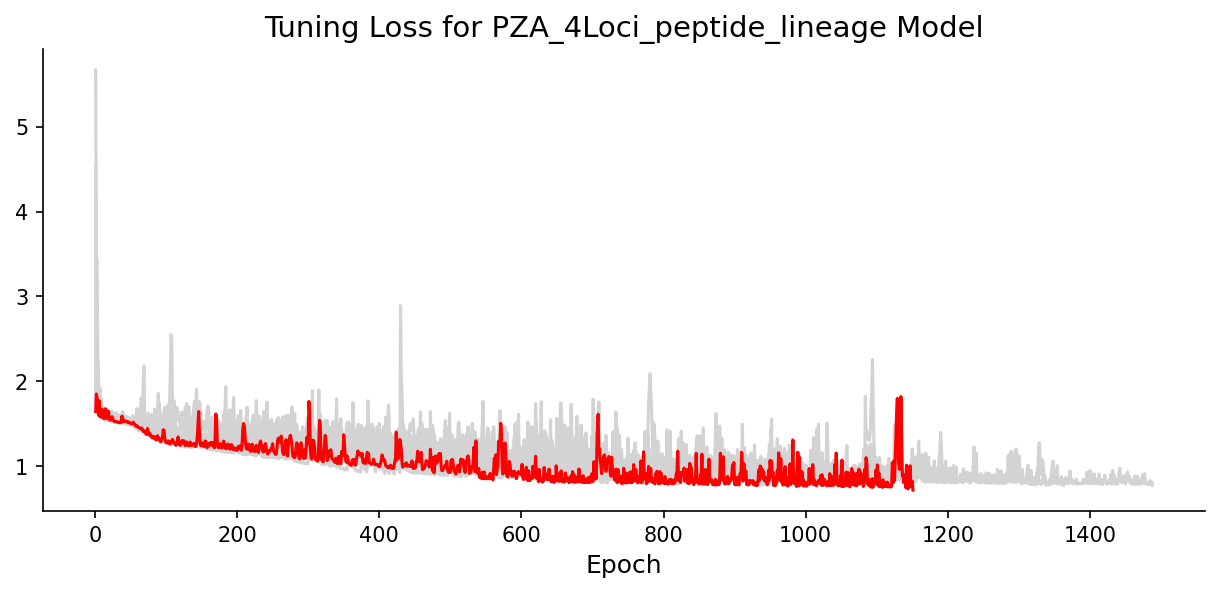

In [3]:
plot_histories(os.path.join(results_path, "PZA_4Loci_peptide_lineage"), binary=False, patience_epochs=150, replicates=True)

# Analyze quantitative CNN

In [2]:
def get_EA_single_model(fName):

    test_pred = pd.read_csv(fName)
    test_pred["y_pred_exp"] = np.round(np.exp2(test_pred["y_pred"]), 2)

    test_pred.loc[(test_pred["lower"] / 2 <= test_pred["y_pred_exp"]) & 
                  (test_pred["y_pred_exp"] <= test_pred["upper"] * 2)
                , "Without_doubling"] = 0
    
    test_pred["Without_doubling"] = test_pred["Without_doubling"].fillna(1).astype(int)
    return test_pred["Without_doubling"].mean()

In [3]:
def plot_ridge_results(path, saveName=None):
    
    pred_df = pd.read_csv(os.path.join(path, "ridge/test_predictions.csv"))
                          
    fig, ax = plt.subplots(figsize=(5, 4))
    
    values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
    kernel = st.gaussian_kde(values)(values)

    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="y_test",
        c=kernel,
        cmap="Blues",
        linewidth=0.25,
        edgecolor="lightgray",
        ax=ax
    )
    
    max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
    min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

    ax.set_xlabel("\nPredicted MIC (µg/mL)", fontsize=9)
    ax.set_ylabel("Actual MIC (µg/mL)", fontsize=9)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    # ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
#     max_log2 = 10
#     ax.set_xticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
#     ax.set_yticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
    
    # smallest_power = -6
    # largest_power = 3
    smallest_power = np.floor(np.min([pred_df.y_pred, pred_df.y_test]))
    largest_power = np.ceil(np.max([pred_df.y_pred, pred_df.y_test]))
    smallest_power = -8
    
    tick_labels = []

    for num in np.exp2(np.linspace(smallest_power, largest_power, 11)):
        if num < 1:
            tick_labels.append(str(np.round(num, 2)))
        else:
            tick_labels.append(str(int(num)))
        
    ax.set_xticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    ax.set_yticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)
        
        
        
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    assert sum(~pd.isnull(x1.query("CV>0")[var].values)) == sum(~pd.isnull(x2.query("CV>0")[var].values))
    return st.mannwhitneyu(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        
        
def compare_two_models(model_1, model_2, test_variables=["Binned_MAE", "Binned_MSE", "Spearman", "Within_1Bin", "Within_doubling", "Sensitivity", "Specificity", "Balanced_Acc"]):
    '''
    Directionality is important. Put the one hypothesized to be better FIRST
    '''
    # lineage does not significantly improve RIF prediction
    for var in test_variables:

        pval = test_for_significance(model_1, model_2, var, alt="two-sided")

        # if the two-sided test is significant, then try one-sided, based on the variable
        if pval < 0.05:

            if "MAE" in var or "MSE" in var or "Without" in var:
                alt = "less"
            else:
                alt = "greater"
        
            pval = test_for_significance(model_1, model_2, var, alt=alt)
            
            if pval < 0.05:
                print(f"{var} better, pval = {pval}")
            else:
                print(f"{var} worse, pval = {1-pval}")
        else:
            print(f"{var}, ns = {pval}")

In [4]:
def get_single_model_results(drug_abbr, output_path, include_lineage=False, include_peptide_length=False, patience=100, bs=True, suffix='', plot=True):
    '''
    Gets results for lineage and regression, using kwargs
    '''

    # naming consistency
    output_path = output_path.replace("_lineage", "").replace("_peptide", "")
    
    if include_peptide_length:
        output_path += "_peptide"
        
    if include_lineage:
        output_path += "_lineage"
        
    model_results_lst = []
    
    df_CNN = quant_model_analysis(os.path.join(results_path, output_path), drug_abbr, include_lineage=include_lineage, include_peptide_length=include_peptide_length, patience=patience, suffix=suffix, bs=bs, plot=plot, saveName=f"{drug_abbr}/CNN_predictions.png")

    # add EA rate (actually 1 - EA, so without_doubling)
    df_CNN.loc[df_CNN['CV'] == 0, "Without_doubling"] = get_EA_single_model(os.path.join(results_path, output_path, f"test_predictions{suffix}.csv"))
    
    df_Reg = pd.read_csv(os.path.join(results_path, output_path, "ridge/results.csv"))
    df_Reg["Lineage"] = int(include_lineage)
    df_Reg["Peptide"] = int(include_peptide_length)

    # add EA rate (actually 1 - EA, so without_doubling)
    # df_Reg.loc[df_Reg['CV'] == 0, "Without_doubling"] = get_EA_single_model(os.path.join(results_path, output_path, "ridge", "test_predictions.csv"))
    
    model_results_lst.append(df_CNN)
    model_results_lst.append(df_Reg)
    
    if bs:
        df_bs_Reg = pd.read_csv(os.path.join(results_path, output_path, "ridge/bootstrapping/results.csv"))
        
        df_CNN.loc[df_CNN['CV'] > 0, "Without_doubling"] = [get_EA_single_model(os.path.join(results_path, output_path, "bootstrapping", f"predictions_{i}{suffix}.csv")) for i in range(10)]
        df_bs_Reg.loc[df_bs_Reg['CV'] > 0, "Without_doubling"] = [get_EA_single_model(os.path.join(results_path, output_path, "ridge", "bootstrapping", f"predictions_{i}.csv")) for i in range(10)]
        
        df_bs_Reg["Lineage"] = int(include_lineage)
        df_bs_Reg["Peptide"] = int(include_peptide_length)
        model_results_lst.append(df_bs_Reg)

    df_combined = pd.concat(model_results_lst, axis=0)
    return df_combined.reset_index(drop=True)

# All Drugs

In [12]:
def get_all_results_single_drug(config_file, suffix=""):

    kwargs = yaml.safe_load(open(f"../config_files/{config_file}", "r"))
    drug_abbr = kwargs["drug"]
    drug = abbr_drug_dict[drug_abbr]
    output_path = kwargs["output_path"]
    plot = False
    bs = True
    
    output_path = output_path.replace("_lineage", "").replace("_peptide", "")

    if drug == "Pyrazinamide":
        patience_epochs = 150
    else:
        patience_epochs = 100
    
    df_base = get_single_model_results(drug_abbr, output_path, include_lineage=False, include_peptide_length=False, patience=patience_epochs, bs=bs, suffix=suffix, plot=plot)

    df_lineage = get_single_model_results(drug_abbr, output_path, include_lineage=True, include_peptide_length=False, patience=patience_epochs, bs=bs,suffix=suffix, plot=plot)

    df_peptide = get_single_model_results(drug_abbr, output_path, include_lineage=False, include_peptide_length=True, patience=patience_epochs, bs=bs, suffix=suffix, plot=plot)

    df_both = get_single_model_results(drug_abbr, output_path, include_lineage=True, include_peptide_length=True, patience=patience_epochs, bs=bs, suffix=suffix, plot=plot)

    df_results = pd.concat([df_base, df_lineage, df_peptide, df_both], axis=0).reset_index(drop=True)
    
    for i, row in df_results.iterrows():
    
        feature_type = ""
    
        if row["Lineage"] == 0 and row["Peptide"] == 0:
            df_results.loc[i, "Feature"] = "Sequence Only"
    
        else:
            if row["Lineage"] == 1:
                feature_type += "+Lineage"
        
            if row["Peptide"] == 1:
                feature_type += "+Peptide"
        
            df_results.loc[i, "Feature"] = feature_type

    return df_results

In [13]:
def plot_single_quant_variable_single_drug(config_file, num_cols_legend=1, legend_loc_1='best', legend_loc_2='best', suffix="", saveName=None):

    plot_df = get_all_results_single_drug(config_file, suffix=suffix)
    plot_df["Model"] = plot_df["Model"].replace("LinReg", "Regression")
    plot_df["Model"] = plot_df["Model"].replace("LogReg", "Regression")
        
    palette = dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex()))

    if plot_df.Model.nunique() == 2:
        hue_order = ["Regression", "CNN"]
    elif plot_df.Model.nunique() == 3:
        hue_order = ["Catalog", "Regression", "CNN"]
    else:
        raise ValueError(f"There should not be {plot_df.Model.nunique()} unique model types")
        
    fig, ax = plt.subplots(1, 2, figsize=(8, 2))

    sns.stripplot(data=plot_df, 
                  x="Feature", 
                  y='Binned_MAE',
                  hue="Model",
                  hue_order=hue_order,
                  palette=palette, 
                  dodge=True, 
                  linewidth=0.5,
                  size=4,
                  edgecolor="gray",
                  ax=ax[0]
                 )

    sns.stripplot(data=plot_df, 
                  x="Feature", 
                  y='Without_doubling',
                  hue="Model",
                  hue_order=hue_order,
                  palette=palette, 
                  dodge=True, 
                  linewidth=0.5,
                  size=4,
                  edgecolor="gray",
                  ax=ax[1]
                 )

    ax[0].set_ylim(top=1.6)
    ax[1].set_ylim(bottom=0)

    font_size = 7
    
    ax[0].tick_params(axis="x", labelsize=font_size-1)
    ax[0].tick_params(axis="y", labelsize=font_size-1)
    ax[0].set_xlabel("")

    ax[1].tick_params(axis="x", labelsize=font_size-1)
    ax[1].tick_params(axis="y", labelsize=font_size-1)
    ax[1].set_xlabel("")
    
    ax[0].set_ylabel('Mean Absolute Error', fontsize=font_size)
    ax[1].set_ylabel('1 - Essential Agreement', fontsize=font_size)

    if legend_loc_1 is None:
        ax[0].get_legend().remove()
    else:
        ax[0].legend(loc=legend_loc_1, ncol=num_cols_legend, fontsize=font_size-1)
        
    if legend_loc_2 is None:
        ax[1].get_legend().remove()
    else:
        ax[1].legend(loc=legend_loc_2, ncol=num_cols_legend, fontsize=font_size-1)
    
    #plt.legend(bbox_to_anchor=(0.7, -0.22), loc="lower right", ncol=plot_df.Model.nunique(), fontsize=font_size)
    sns.despine()
        
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')

    return plot_df

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide_lineage


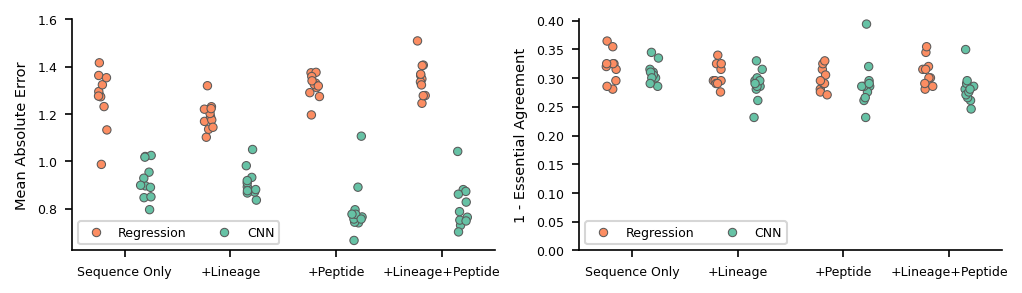

In [7]:
PZA_results = plot_single_quant_variable_single_drug("config_pza.yaml", num_cols_legend=2, legend_loc_1='lower left', legend_loc_2='lower left', lowAF=False, saveName='PZA/MAE_EA.png')

In [100]:
var = 'Without_doubling'

print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                    PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                    PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

MannwhitneyuResult(statistic=92.0, pvalue=0.020462398834419245)
MannwhitneyuResult(statistic=70.0, pvalue=0.27636544467094193)
MannwhitneyuResult(statistic=95.5, pvalue=0.011469453062716644)
MannwhitneyuResult(statistic=80.0, pvalue=0.10517638558115544)


In [27]:
# var = 'Without_doubling'

# print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
#                     PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
#                       alternative='greater'
#                    ))

# print(st.mannwhitneyu(PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
#                     PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
#                       alternative='greater'
#                    ))

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage


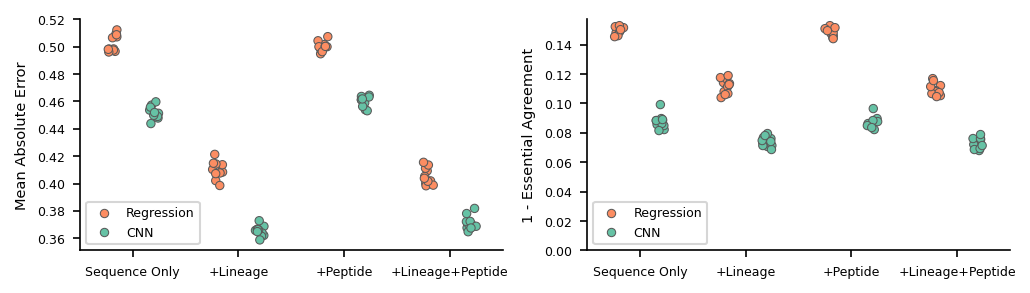

In [21]:
MXF_results = plot_single_quant_variable_single_drug("config_mxf.yaml", num_cols_legend=1, legend_loc_1='lower left', legend_loc_2="lower left", saveName='MXF/MAE_EA.png')

In [104]:
var = 'Without_doubling'

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

MannwhitneyuResult(statistic=121.0, pvalue=3.98211137138711e-05)
MannwhitneyuResult(statistic=121.0, pvalue=4.0007099926356576e-05)
MannwhitneyuResult(statistic=67.5, pvalue=0.3338248561964807)
MannwhitneyuResult(statistic=70.5, pvalue=0.26573487530031903)


/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide_lineage


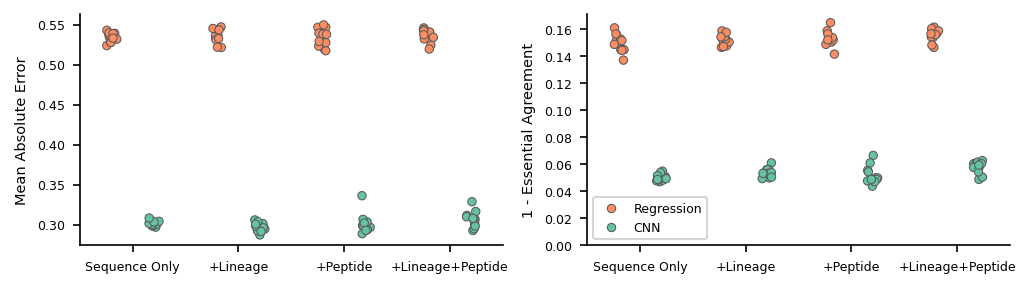

In [22]:
RIF_results = plot_single_quant_variable_single_drug("config_rif.yaml", num_cols_legend=1, legend_loc_1=None, legend_loc_2='lower left', saveName='RIF/MAE_EA.png')

In [108]:
var = 'Without_doubling'

print(st.mannwhitneyu(RIF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                      alternative='less'
                   ))

print(st.mannwhitneyu(RIF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                    RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='less'
                   ))

print(st.mannwhitneyu(RIF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    RIF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                    RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='less'
                   ))

MannwhitneyuResult(statistic=23.5, pvalue=0.008102817896116079)
MannwhitneyuResult(statistic=28.0, pvalue=0.017600332160132272)
MannwhitneyuResult(statistic=57.0, pvalue=0.603851880766144)
MannwhitneyuResult(statistic=29.0, pvalue=0.02066377960473094)


In [90]:
RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var].mean(), RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var].mean()

(0.29697569655563627, 0.3066164383069365)

In [95]:
RIF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var].mean(), RIF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var].mean()

(0.3016053217416847, 0.29697569655563627)

In [ ]:
The Rifampicin model replicates have low variance, so clinically irrelevant error differences produce statistically significant p-values. Lineage SNPs slghtly decrease error in models without peptide lengths from 0.302 to 0.297 (p = 0.02), and peptide lengths  slightly increase error in models with lineage from 0.297 to 0.307 (p = 0.005).

In [ ]:
 However, this

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage


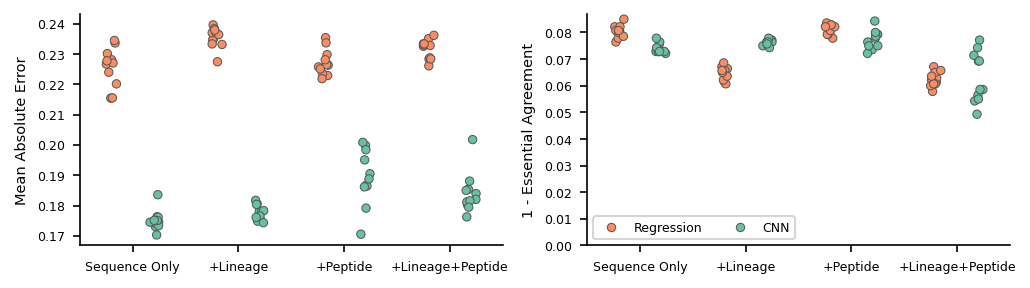

In [23]:
LEV_results = plot_single_quant_variable_single_drug("config_lev.yaml", num_cols_legend=2, legend_loc_1=None, legend_loc_2='lower left', saveName='LEV/MAE_EA.png')

In [167]:
var = 'Without_doubling'

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                      alternative='less'
                   ))

print(st.mannwhitneyu(MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                    MXF_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                      alternative='greater'
                   ))

MannwhitneyuResult(statistic=121.0, pvalue=3.98211137138711e-05)
MannwhitneyuResult(statistic=121.0, pvalue=4.0007099926356576e-05)
MannwhitneyuResult(statistic=67.5, pvalue=0.6898529923254195)
MannwhitneyuResult(statistic=70.5, pvalue=0.26573487530031903)


In [113]:
print(st.mannwhitneyu(LEV_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                    LEV_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                      alternative='less'
                   ))

MannwhitneyuResult(statistic=23.5, pvalue=0.007668814896687762)


In [115]:
LEV_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var].mean(), LEV_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var].mean()

(0.07402597402597402, 0.07590909090909091)

In [164]:
MXF_results.query("Model=='CNN'").groupby(['Lineage', 'Peptide'])['Binned_MAE'].mean().sort_values()

Lineage  Peptide
1        0          0.365226
         1          0.371360
0        0          0.451861
         1          0.460017
Name: Binned_MAE, dtype: float64

In [165]:
MXF_results.query("Model=='CNN'").groupby(['Lineage', 'Peptide'])['Without_doubling'].mean().sort_values()

Lineage  Peptide
1        1          0.073049
         0          0.074099
0        1          0.087139
         0          0.087634
Name: Without_doubling, dtype: float64

In [157]:
LEV_results.query("Model=='CNN'").groupby(['Lineage', 'Peptide'])['Without_doubling'].mean().sort_values()

Lineage  Peptide
1        1          0.063052
0        0          0.074026
1        0          0.075909
0        1          0.077403
Name: Without_doubling, dtype: float64

In [ ]:
6.31-7.74

In [ ]:
The range of Rifampicin essential disagreeements is 5.04-5.78%

In [153]:
PZA_results.groupby(['Model', 'Lineage', 'Peptide'])['Without_doubling'].mean().sort_values()

Model       Lineage  Peptide
CNN         1        1          0.282132
                     0          0.288401
            0        1          0.290193
Regression  0        1          0.295567
            1        0          0.303180
                     1          0.308106
CNN         0        0          0.308554
Regression  0        0          0.317510
Name: Without_doubling, dtype: float64

In [154]:
LEV_results.groupby(['Model', 'Lineage', 'Peptide'])['Without_doubling'].mean().sort_values()

Model       Lineage  Peptide
Regression  1        1          0.062468
CNN         1        1          0.063052
Regression  1        0          0.064805
CNN         0        0          0.074026
            1        0          0.075909
            0        1          0.077403
Regression  0        0          0.080390
                     1          0.081169
Name: Without_doubling, dtype: float64

In [155]:
MXF_results.groupby(['Model', 'Lineage', 'Peptide'])['Without_doubling'].mean().sort_values()

Model       Lineage  Peptide
CNN         1        1          0.073049
                     0          0.074099
            0        1          0.087139
                     0          0.087634
Regression  1        1          0.109449
                     0          0.111860
            0        1          0.148569
                     0          0.149744
Name: Without_doubling, dtype: float64

In [140]:
var = 'Without_doubling'

print(st.mannwhitneyu(PZA_results.query("Model=='Regression' & Lineage==0 & Peptide==0")[var],
                PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                alternative='two-sided'
               ))

print(st.mannwhitneyu(PZA_results.query("Model=='Regression' & Lineage==0 & Peptide==1")[var],
                PZA_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                alternative='two-sided'
               ))

print(st.mannwhitneyu(PZA_results.query("Model=='Regression' & Lineage==1 & Peptide==0")[var],
                PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                alternative='two-sided'
               ))

print(st.mannwhitneyu(PZA_results.query("Model=='Regression' & Lineage==1 & Peptide==1")[var],
                PZA_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                alternative='greater'
               ))

MannwhitneyuResult(statistic=73.5, pvalue=0.4101625042465742)
MannwhitneyuResult(statistic=75.0, pvalue=0.35643546523693637)
MannwhitneyuResult(statistic=78.5, pvalue=0.2464577867072556)
MannwhitneyuResult(statistic=99.0, pvalue=0.006119246867203101)


In [151]:
var = 'Without_doubling'

print(st.mannwhitneyu(LEV_results.query("Model=='Regression' & Lineage==0 & Peptide==0")[var],
                LEV_results.query("Model=='CNN' & Lineage==0 & Peptide==0")[var],
                alternative='greater'
               ))

print(st.mannwhitneyu(LEV_results.query("Model=='Regression' & Lineage==0 & Peptide==1")[var],
                LEV_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var],
                alternative='greater'
               ))

print(st.mannwhitneyu(LEV_results.query("Model=='Regression' & Lineage==1 & Peptide==0")[var],
                LEV_results.query("Model=='CNN' & Lineage==1 & Peptide==0")[var],
                alternative='less'
               ))

print(st.mannwhitneyu(LEV_results.query("Model=='Regression' & Lineage==1 & Peptide==1")[var],
                LEV_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var],
                alternative='greater'
               ))

MannwhitneyuResult(statistic=119.0, pvalue=6.175823601209103e-05)
MannwhitneyuResult(statistic=101.0, pvalue=0.004144676319107578)
MannwhitneyuResult(statistic=0.0, pvalue=3.8719015259474084e-05)
MannwhitneyuResult(statistic=64.0, pvalue=0.42185034597252463)


In [116]:
LEV_results.query("Model=='CNN' & Lineage==0 & Peptide==1")[var].mean(), LEV_results.query("Model=='CNN' & Lineage==1 & Peptide==1")[var].mean()

(0.07740259740259739, 0.06305194805194805)

In [117]:
LEV_results.query("Model=='Regression' & Lineage==0 & Peptide==0")[var].mean(), LEV_results.query("Model=='Regression' & Lineage==1 & Peptide==0")[var].mean()

(0.0803896103896104, 0.06480519480519481)

In [118]:
LEV_results.query("Model=='Regression' & Lineage==0 & Peptide==1")[var].mean(), LEV_results.query("Model=='Regression' & Lineage==1 & Peptide==1")[var].mean()

(0.08116883116883117, 0.06246753246753247)

In [ ]:
The addition of peptide lengths and lineage slightly increases mean absolute error for Levofloxacin. Mean absolute errors for sequence only, + Lineage, + Peptide, and + Lineage + Peptide models are 0.175, 0.178, 0.189, and 0.184 log2-MIC, respectively. 

In [52]:
LEV_peptide_lengths = pd.read_csv(os.path.join(results_path, "LEV_gyrBA", "gene_peptide_lengths.csv"))
df_LEV = pd.read_csv(os.path.join(data_path, "LEV", "data_for_model.csv"))
LEV_pred = pd.read_csv(os.path.join(results_path, "LEV_gyrBA", "test_predictions.csv"))

In [36]:
LEV_peptide_lengths.gyrB_length.value_counts()

gyrB_length
675    6998
674       3
Name: count, dtype: int64

In [37]:
LEV_peptide_lengths.gyrA_length.value_counts()

gyrA_length
838    6999
836       1
819       1
Name: count, dtype: int64

In [49]:
LEV_peptide_lengths.query("gyrA_length==819")

,Unnamed: 0,gyrB_length,gyrA_length
1553,ERR4822407,675,819


In [51]:
df_LEV.query("ROLLINGDB_ID=='ERR4822407'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,LEV,LEV_lower_bound,LEV_midpoint,LEV_upper_bound,LEV_quality,Path,Coll2014,Binary,Lineage,category
1553,ERR4822407,ERS5312471,site.03.subj.UA21-2017.lab.UA21-2017.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set


In [53]:
LEV_pred.query("Isolate=='ERR4822407'")

,Isolate,y_test,lower,upper,y_pred,compute_error
285,ERR4822407,-2.434403,0.12,0.25,-1.947323,1


0.2592969245511707

In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9913" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/ERR4822407/pilon/ERR4822407.eff.vcf

# Binary Statistics: Compare with 2021 WHO Catalog

## Predicted R if any 1) Assoc w R or 2) Assoc w R - Interim mutation is present

In [14]:
def plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix="", sigFig=1, saveName=None):
        
    assert len(drug_order) == len(config_files_lst)
    df_combined = []
    
    for config_file in config_files_lst:
            
        # get model results
        df_quant = get_all_results_single_drug(config_file, suffix=suffix)
        df_quant["Model"] = df_quant["Model"].replace("LinReg", "Regression")
        df_quant["Model"] = df_quant["Model"].replace("LogReg", "Regression")
    
        kwargs = yaml.safe_load(open(f"../config_files/{config_file}", "r"))
        drug_abbr = kwargs["drug"]
        drug = abbr_drug_dict[drug_abbr]
        output_path = kwargs["output_path"].replace("_lineage", "").replace("_peptide", "")
    
        # catalog classification results -- no lineage models because catalog classification doesn't use lineage
        df_catalog = pd.read_csv(os.path.join(results_path, output_path, "validation", f"catalog_stats{suffix}.csv")).query("Dataset=='Test'")
        df_catalog['Drug'] = drug_abbr
    
        # not actually true (catalog doesn't use lineage or peptide lengths, but set to 1 because for the other models, we're going to keep those models, and this makes querying easier)
        df_catalog['Lineage'] = 1
        df_catalog['Peptide'] = 1
    
        df_combined.append(pd.concat([df_quant, df_catalog], axis=0))
    
    df_combined = pd.concat(df_combined, axis=0).query("Lineage==1 & Peptide==1").reset_index(drop=True)
    df_combined[plot_var] *= 100
    # df_combined['Drug'] = df_combined['Drug'].map(abbr_drug_dict)

    fig, ax = plt.subplots(figsize=(8, 4))
    
    sns.barplot(data=df_combined,
                x="Drug", 
                order=drug_order,
                y=plot_var, 
                hue="Model",
                hue_order=["Catalog", "Regression", "CNN"],
                errorbar=("pi", 95),
                errwidth=0.75,
                capsize=0.05,
                edgecolor="black",
                linewidth=0.5,
                palette=dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex())),
                ax=ax
                )

    ax.set_xticks(ticks=ax.get_xticks(), labels=[abbr_drug_dict[val.get_text()] for val in ax.get_xticklabels()])
    sns.despine()

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(plot_var)    
    ax.set_ylim(bottom=0, top=100)

    # Add labels on top of each bar
    for p in ax.patches:

        if p.get_height() > 0:

            label = np.round(p.get_height(), sigFig)
            
            ax.annotate(f'{label}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')

    # ax.legend(bbox_to_anchor=(1.27, 0.35), loc="lower right")
    ax.legend(bbox_to_anchor=(0.76, -0.2), loc="lower right", ncol=3, fontsize=9)
        
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')

    return df_combined

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_pept

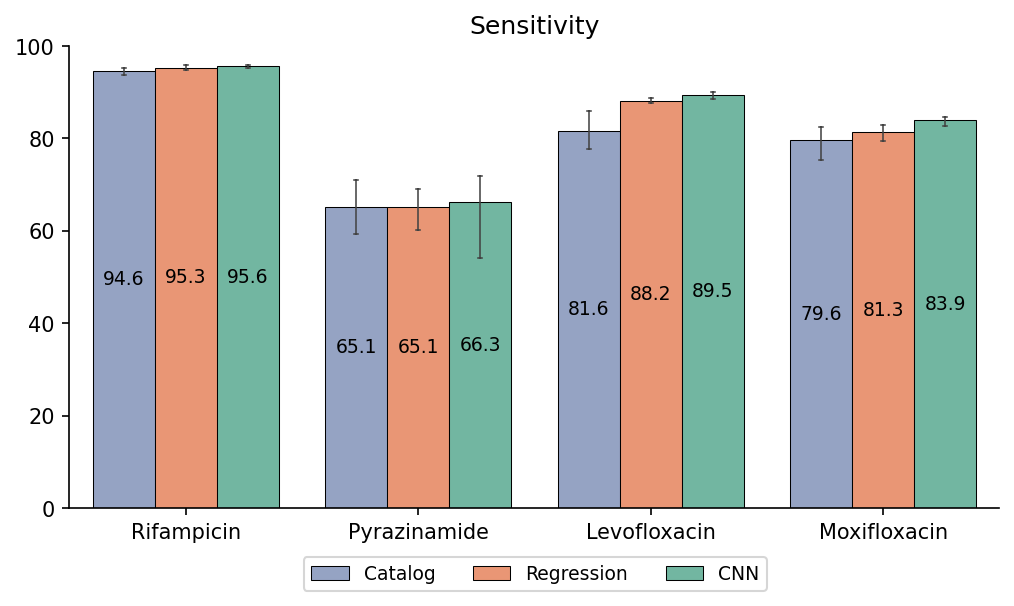

In [15]:
plot_var = "Sensitivity"
drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']

sensitivity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix="", sigFig=1, saveName="fourDrug_sensitivity_with_catalog.png")

In [28]:
RIF_lowAF = pd.read_csv(os.path.join(results_path, "RIF_rpoABC", "validation/catalog_stats_lowAF.csv")).query("Dataset=='Test'")

In [30]:
RIF_lowAF['Sensitivity'].mean()

0.9592779453869361

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage


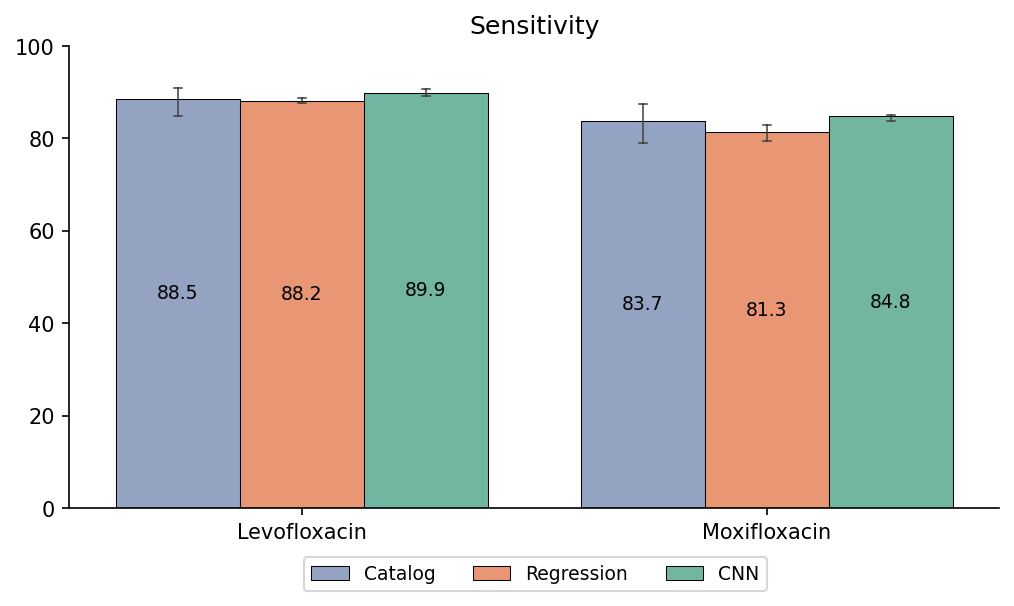

In [21]:
plot_var = "Sensitivity"
# drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
# config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']
drug_order = ['LEV', 'MXF']
config_files_lst = ['config_lev.yaml', 'config_mxf.yaml']

sensitivity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix="_lowAF", sigFig=1, saveName="fourDrug_sensitivity_with_catalog_HET.png")

In [27]:
st.mannwhitneyu(sensitivity_metrics.query("Drug=='LEV' & Model=='CNN'")['Sensitivity'],
                sensitivity_metrics.query("Drug=='LEV' & Model=='Catalog'")['Sensitivity'],
                alternative='greater'
               )

MannwhitneyuResult(statistic=92.0, pvalue=0.019861122945021084)

In [30]:
st.mannwhitneyu(sensitivity_metrics.query("Drug=='MXF' & Model=='CNN'")['Sensitivity'],
                sensitivity_metrics.query("Drug=='MXF' & Model=='Catalog'")['Sensitivity'],
                alternative='greater'
               )

MannwhitneyuResult(statistic=90.5, pvalue=0.023552911864430745)

In [60]:
search_lst = who_variants.query("drug=='PZA' & confidence in ['1) Assoc w R', '2) Assoc w R - interim'] & mutation.str.contains('_c.')").mutation.values
who_variants.query("drug=='PZA' & confidence in ['1) Assoc w R', '2) Assoc w R - interim'] & mutation.str.contains('_c.')")

,drug,genome_index,confidence,mutation,gene,variant
20,PZA,2289252,1) Assoc w R,pncA_c.-11A>G,pncA,c.-11A>G
26,PZA,2289252,1) Assoc w R,pncA_c.-11A>C,pncA,c.-11A>C
137,PZA,2289245,1) Assoc w R,pncA_c.-5delG,pncA,c.-5delG


In [72]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants_fixed_annot.csv"))

In [85]:
# catalog_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/catalog_test_predictions.csv")

# search_isolates = catalog_pred.query("y_test == 1 and y_pred==0").Isolate.values
# PZA_isolate_variants.query("Isolate in @search_isolates").merge(who_variants[['mutation', 'confidence']], on='mutation', how='left')

In [68]:
# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289251delA', 'mutation'] = 'pncA_c.-10delT'
# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289251A>G', 'mutation'] = 'pncA_c.-10T>C'

# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289252T>C', 'mutation'] = 'pncA_c.-11A>G'
# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289252T>A', 'mutation'] = 'pncA_c.-11A>T'
# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289252T>G', 'mutation'] = 'pncA_c.-11A>C'

# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289254_2289255insT', 'mutation'] = 'pncA_c.-13_-14insA'

# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289256T>C', 'mutation'] = 'pncA_c.-15A>G'
# # PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA-Rv2044c_n.2289257T>C', 'mutation'] = 'pncA_c.-16A>G'

# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-10delT', 'mutation'] = 'pncA_c.-10delT'
# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-10T>C', 'mutation'] = 'pncA_c.-10T>C'

# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-11A>G', 'mutation'] = 'pncA_c.-11A>G'
# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-11A>T', 'mutation'] = 'pncA_c.-11A>T'
# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-11A>C', 'mutation'] = 'pncA_c.-11A>C'

# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-13_-14insA', 'mutation'] = 'pncA_c.-13_-14insA'

# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-15A>G', 'mutation'] = 'pncA_c.-15A>G'
# PZA_isolate_variants.loc[PZA_isolate_variants['mutation']=='pncA_-16A>G', 'mutation'] = 'pncA_c.-16A>G'

In [12]:
# plot_var = "Sensitivity"
# drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
# config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']

# sensitivity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix='_lowAF', sigFig=1, saveName="fourDrug_sensitivity_with_catalog_witHET.png")

In [87]:
var = 'Sensitivity'

st.mannwhitneyu(sensitivity_metrics.query("Drug=='PZA' & Model=='Catalog'")[var],
                sensitivity_metrics.query("Drug=='PZA' & Model=='CNN'")[var],
                alternative='less'
               )

MannwhitneyuResult(statistic=41.0, pvalue=0.10575937783398986)

In [14]:
var = 'Specificity'

st.mannwhitneyu(sensitivity_metrics.query("Drug=='PZA' & Model=='Catalog'")[var],
                sensitivity_metrics.query("Drug=='PZA' & Model=='CNN'")[var],
                alternative='less'
               )

MannwhitneyuResult(statistic=46.0, pvalue=0.1773949346431553)

In [15]:
var = 'Sensitivity'

st.mannwhitneyu(sensitivity_metrics.query("Drug=='PZA' & Model=='CNN'")[var],
                sensitivity_metrics.query("Drug=='PZA' & Model=='Regression'")[var],
                alternative='two-sided'
               )

MannwhitneyuResult(statistic=79.0, pvalue=0.23455723443148258)

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_pept

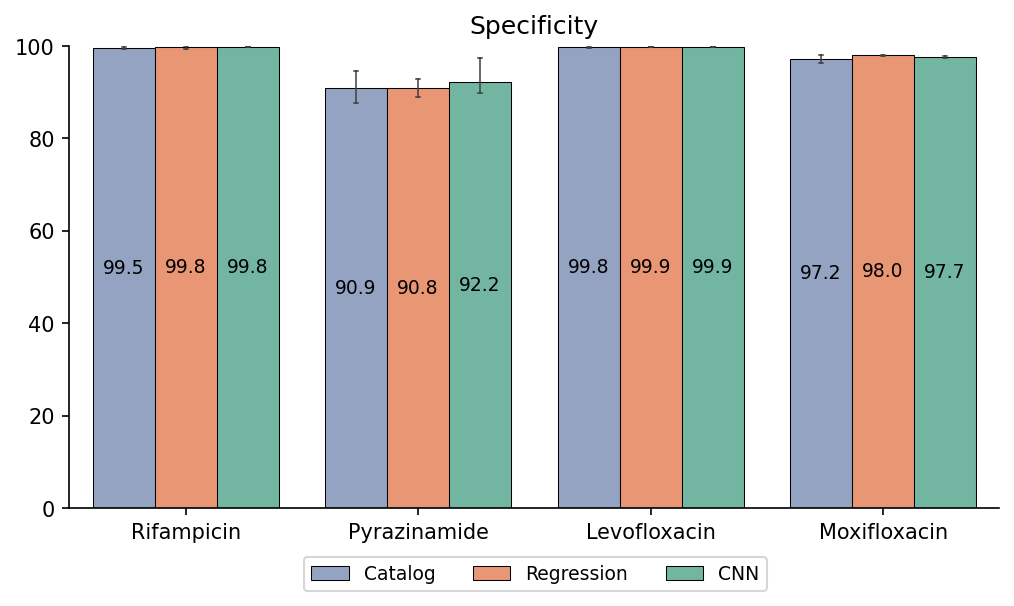

In [76]:
plot_var = "Specificity"
drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']

specificity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix='', sigFig=1)#, saveName="fourDrug_specificity_with_catalog.png")

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_pept

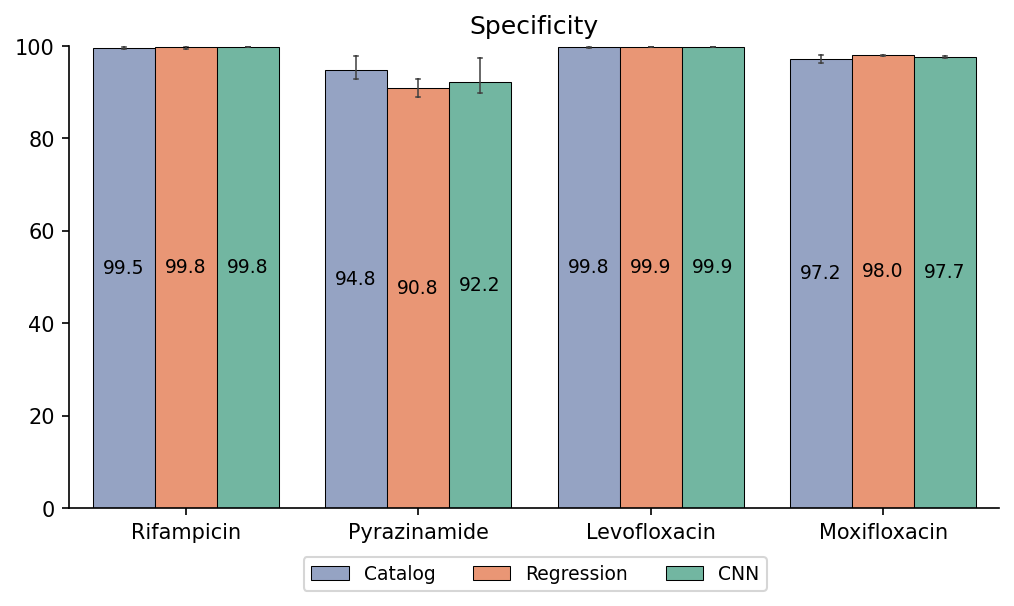

In [16]:
plot_var = "Specificity"
drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']

specificity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix='', sigFig=1, saveName="fourDrug_specificity_with_catalog.png")

In [17]:
# plot_var = "Specificity"
# drug_order = ['RIF', 'PZA', 'LEV', 'MXF']
# config_files_lst = ['config_rif.yaml', 'config_lev.yaml', 'config_mxf.yaml', 'config_pza.yaml']

# specificity_metrics = plot_binary_variable_all_drugs(config_files_lst, plot_var, drug_order, suffix='_lowAF', sigFig=1, saveName="fourDrug_specificity_with_catalog_withHET.png")

In [88]:
def compare_model_stats(df_results, var, drugs_lst, model_1, model_2):
    
    for drug in drugs_lst:
        
        _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                  df_results.query("Drug==@drug & Model==@model_2")[var],
                                  alternative='two-sided'
                                 )
    
        if pval < 0.05:
    
            _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                      df_results.query("Drug==@drug & Model==@model_2")[var],
                                      alternative='greater'
                                     )
    
            if pval < 0.05:
                final_str = "Greater"
                final_pval = pval
            else:
                _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                          df_results.query("Drug==@drug & Model==@model_2")[var],
                                          alternative='less'
                                         )    
                if pval < 0.05:
                    final_str = "Less"
                    final_pval = pval
                else:
                    final_str = "IDK"
                    finale_pval = pval
        else:
            final_str = "Same"
    
        print(drug, final_str, pval)
    print("\n")

In [93]:
var = "Sensitivity"
compare_model_stats(sensitivity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Catalog")
# compare_model_stats(df_binary_results, var, ['RIF', 'PZA', 'LEV', 'MXF'], "Regression", "Catalog")
compare_model_stats(sensitivity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Regression")

RIF Greater 6.572816724775085e-05
PZA Same 0.21151875566797973
LEV Greater 3.74628541450451e-05
MXF Greater 5.0655949174195786e-05


RIF Greater 0.023185207551987635
PZA Same 0.23455723443148258
LEV Greater 0.00010544877245752066
MXF Greater 9.448088097439107e-05




In [94]:
var = "Specificity"
compare_model_stats(specificity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Catalog")
# compare_model_stats(df_binary_results, var, ['RIF', 'PZA', 'LEV', 'MXF'], "Regression", "Catalog")
compare_model_stats(specificity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Regression")

RIF Greater 0.0008503244356746148
PZA Same 0.21022295330345908
LEV Same 0.06994493097385401
MXF Greater 0.0028191315078251247


RIF Same 0.13752876763616464
PZA Same 0.24194507764331896
LEV Same 0.3534921156860199
MXF Less 0.00020663201889914445




# Which Isolates Were Missed by Catalog or Models for PZA, MXF, and LEV?

In [83]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants_fixed_annot.csv"))

PZA_CNN_pred = pd.read_csv(os.path.join(results_path, "PZA_4Loci_peptide_lineage", "test_predictions.csv")).rename(columns={'y_pred': 'y_pred_log2_MIC'})
PZA_CNN_pred['y_pred'] = (PZA_CNN_pred['y_pred_log2_MIC'] > np.log2(100)).astype(int)

PZA_catalog_pred = pd.read_csv(os.path.join(results_path, "PZA_4Loci", "catalog_test_predictions_lowAF.csv"), usecols=['Isolate', 'y_pred']).rename(columns={'y_pred': 'y_pred_catalog'})
PZA_CNN_pred = PZA_CNN_pred.merge(PZA_catalog_pred)

In [186]:
MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF", "isolate_variants_fixed_annot.csv"))

MXF_CNN_pred = pd.read_csv(os.path.join(results_path, "MXF_gyrBA_peptide_lineage", "test_predictions.csv")).rename(columns={'y_pred': 'y_pred_log2_MIC'})
MXF_CNN_pred['y_pred'] = (MXF_CNN_pred['y_pred_log2_MIC'] > np.log2(0.5)).astype(int)

MXF_catalog_pred = pd.read_csv(os.path.join(results_path, "MXF_gyrBA", "catalog_test_predictions_lowAF.csv"), usecols=['Isolate', 'y_pred']).rename(columns={'y_pred': 'y_pred_catalog'})
MXF_CNN_pred = MXF_CNN_pred.merge(MXF_catalog_pred)

df_MXF = pd.read_csv(os.path.join(data_path, "MXF", "data_for_model.csv"))

In [187]:
# TP / TP + FN. So look for missed true positives and false negatives

# false negatives
search_isolates = MXF_CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > 0.5").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
MXF_CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > 0.5").sort_values("upper", ascending=False)

5


,Isolate,y_test,lower,upper,y_pred_log2_MIC,compute_error,y_pred,y_pred_catalog
463,ERR4797524,1.000000,2.0,inf,-1.151815,1,0,1
519,ERR4812196,1.000000,2.0,inf,-1.690425,1,0,1
829,ERR2510847,1.000000,2.0,inf,-2.794118,1,0,1
1463,SAMN02398713,0.584963,1.0,2.0,-2.418094,1,0,1
936,ERR4831432,-0.415037,0.5,1.0,-1.236186,1,0,1


In [188]:
MXF_CNN_pred.query("y_pred_catalog==1 & upper > 0.5").shape,  MXF_CNN_pred.query("y_pred==1 & upper > 0.5").shape

((207, 8), (203, 8))

In [189]:
MXF_CNN_pred.query("y_pred_catalog==0 & upper > 0.5").shape,  MXF_CNN_pred.query("y_pred==0 & upper > 0.5").shape

((33, 8), (37, 8))

In [181]:
207/(207+33), 203/(203+37)

(0.8625, 0.8458333333333333)

In [ ]:
Catalog gets two more true positives and two fewer false negatives

In [ ]:
# TP / TP + FN. So look for missed true positives and false negatives
search_isolates = MXF_CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > 0.5").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
MXF_CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > 0.5").sort_values("upper", ascending=False)

In [168]:
MXF_isolate_variants.query("Isolate in @search_isolates & mutation not in ['gyrA_p.Glu21Gln', 'gyrA_p.Ser95Thr', 'gyrA_p.Gly668Asp']").merge(who_variants.query("drug=='Moxifloxacin'")[['mutation', 'confidence']])

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,confidence
0,6620,G,A,Amb,0.27,gyrB,missense_variant,c.1381G>A,p.Asp461Asn,ERR2510847,gyrB_p.Asp461Asn,2) Assoc w R - Interim
1,7563,G,T,Amb,0.67,gyrA,missense_variant,c.262G>T,p.Gly88Cys,ERR4812196,gyrA_p.Gly88Cys,1) Assoc w R
2,8040,G,A,PASS,1.0,gyrA,missense_variant,c.739G>A,p.Gly247Ser,ERR4812196,gyrA_p.Gly247Ser,5) Not assoc w R
3,6579,C,T,PASS,1.0,gyrB,missense_variant,c.1340C>T,p.Ser447Phe,SAMN02398713,gyrB_p.Ser447Phe,2) Assoc w R - Interim


In [161]:
df_MXF.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category
2570,ERR4812196,ERS5302356,site.05.subj.CA-1199.lab.CO-00979-19.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.0,2.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.3.3,1,4,original_test_set
4007,ERR2510847,ERS2395163,site.06.subj.06TB_0406.lab.06MIL0997.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.0,2.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.2.1,1,4,original_test_set
7327,SAMN02398713,SAMN02398713,1417028.3,South Korea,PATRIC_20191206,"Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,"Masan, Korea or Kampala, Uganda",m7h10,1-2,1.0,1.5,2.0,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.2,1,2,original_test_set


In [162]:
who_variants.query("mutation=='gyrA_p.Asp94Ala'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
29346,Levofloxacin,gyrA,p.Asp94Ala,gyrA_p.Asp94Ala,1,missense_variant,1.0,386.0,313.0,73.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,7582
33233,Moxifloxacin,gyrA,p.Asp94Ala,gyrA_p.Asp94Ala,1,missense_variant,1.0,320.0,168.0,152.0,...,1) Assoc w R,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,NaN,F,1,7582


In [158]:
df_MXF.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category
2276,ERR4797524,ERS5282548,site.04.subj.01356.lab.723428.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.0,2.00,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,3,1,3,original_test_set
2570,ERR4812196,ERS5302356,site.05.subj.CA-1199.lab.CO-00979-19.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.0,2.00,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.3.3,1,4,original_test_set
4007,ERR2510847,ERS2395163,site.06.subj.06TB_0406.lab.06MIL0997.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>2.0,2.0,2.00,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.2.1,1,4,original_test_set
4528,ERR4831432,ERS5281720,site.06.subj.GDH-788.lab.06MIL1043.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,1.0,0.5,0.75,1.0,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,3,1,3,original_test_set
7327,SAMN02398713,SAMN02398713,1417028.3,South Korea,PATRIC_20191206,"Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,"Masan, Korea or Kampala, Uganda",m7h10,1-2,1.0,1.50,2.0,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.2,1,2,original_test_set


In [ ]:
Two L3 isolates (ERR4797524 and ERR4831432) are underpredicted by the CNN, despite containing Moxifloxacin resistance-associated variants (gyrA_p.Asp94Ala and gyrA_p.Ala90Val). These isolates are predicted resistant by the model without lineage SNPs, and the two variants are predicted in silico to elevate MIC (0.45 and 0.66 µg/mL, respectively), suggesting that lineage information can inappropriately skew MIC predictions. 

In [ ]:
['gyrA_p.Ala90Val', 'gyrA_p.Asp94Ala', 'gyrA_p.Gly88Cys', 'gyrB_p.Asp461Asn', 'gyrB_p.Ser447Phe']

# Individual Model Predictions Scatterplots

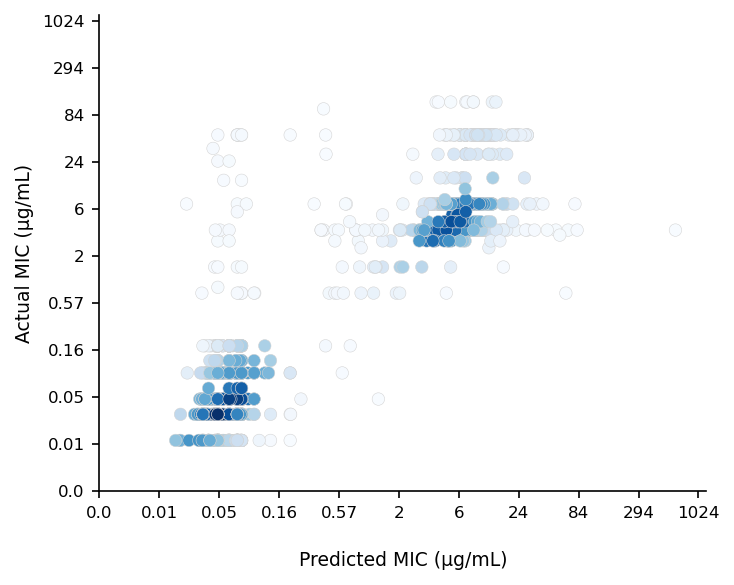

In [234]:
plot_ridge_results(os.path.join(results_path, "RIF_rpoABC"), )#saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))

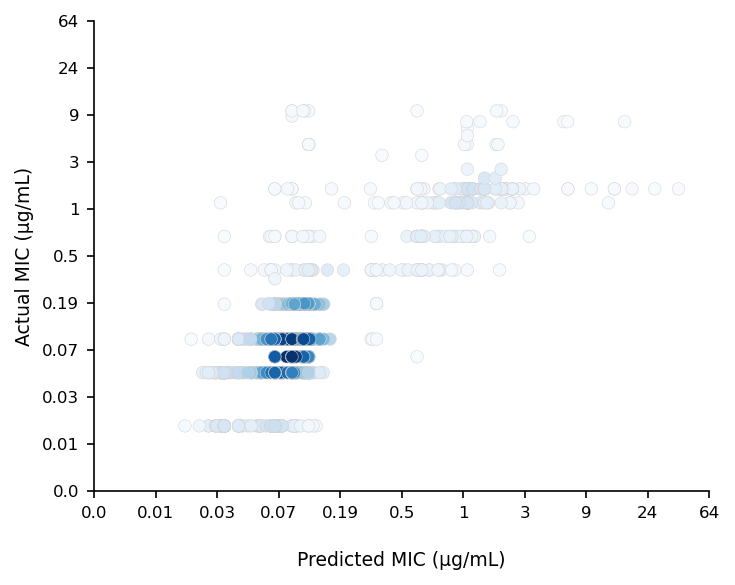

In [237]:
plot_ridge_results(os.path.join(results_path, "MXF_gyrBA_lineage"), )#saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))

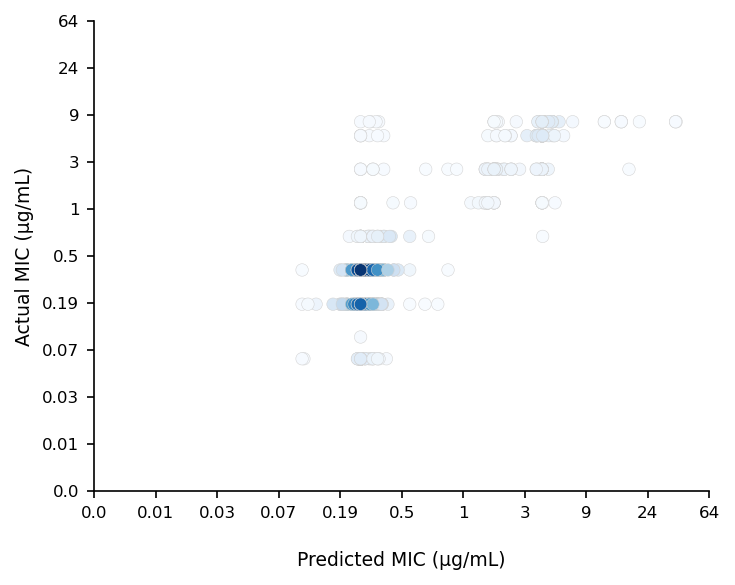

In [238]:
plot_ridge_results(os.path.join(results_path, "LEV_gyrBA"), )#saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))